In [1]:
!pip install ntscraper


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import requests
from bs4 import BeautifulSoup
import json
from datetime import datetime

username = "pusholder"

# Twitter Syndication API üzerinden tweetleri çek
url = f"https://syndication.twitter.com/srv/timeline-profile/screen-name/{username}"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
}

response = requests.get(url, headers=headers)

if response.status_code == 200:
    soup = BeautifulSoup(response.text, "html.parser")
    script_tag = soup.find("script", {"id": "__NEXT_DATA__"})
    data = json.loads(script_tag.string)
    entries = data["props"]["pageProps"]["timeline"]["entries"]

    tweet_count = 0
    for entry in entries:
        if entry["type"] != "tweet":
            continue
        tweet_count += 1
        if tweet_count > 10:
            break

        tw = entry["content"]["tweet"]
        tweet_id = tw.get("id_str", "")
        text = tw.get("text", "")
        created = tw.get("created_at", "")
        likes = tw.get("favorite_count", 0)
        rts = tw.get("retweet_count", 0)
        replies = tw.get("reply_count", 0)
        quotes = tw.get("quote_count", 0)

        # Tarihi formatla
        try:
            dt = datetime.strptime(created, "%a %b %d %H:%M:%S %z %Y")
            tarih = dt.strftime("%d/%m/%Y %H:%M")
        except:
            tarih = created

        # URL'leri temizle (t.co linklerini kaldır)
        import re
        clean_text = re.sub(r'https?://t\.co/\S+', '', text).strip()

        link = f"https://x.com/{username}/status/{tweet_id}"

        print(f"{'='*60}")
        print(f"📌 Tweet {tweet_count}  |  {tarih}")
        print(f"📝 {clean_text}")
        print(f"❤️ {likes}  🔁 {rts}  💬 {replies}  🔄 {quotes}")
        print(f"🔗 {link}")
        print()

    print(f"✅ Toplam {tweet_count} tweet başarıyla çekildi.")
else:
    print(f"Hata: {response.status_code}")

📌 Tweet 1  |  28/02/2026 20:16
📝 ABD'li üst düzey yetkililer: "Hamaney'in ölü bedeninin fotoğrafı Trump'a gösterildi."
❤️ 22  🔁 0  💬 5  🔄 0
🔗 https://x.com/pusholder/status/2027840227004276824

📌 Tweet 2  |  28/02/2026 19:25
📝 Lucas Torreira: "Şampiyonlar Ligi'nde Türk bayrağını temsil ediyoruz."
❤️ 5235  🔁 66  💬 96  🔄 8
🔗 https://x.com/pusholder/status/2027827557366653347

📌 Tweet 3  |  28/02/2026 19:20
📝 Dubai semalarında İran füzeleri görüntülendi.
❤️ 1447  🔁 19  💬 46  🔄 5
🔗 https://x.com/pusholder/status/2027826344617284083

📌 Tweet 4  |  28/02/2026 19:02
📝 Devlet Bahçeli: "ABD’nin İran’a beklenen saldırısı terör devleti İsrail tarafından yapıldı."
❤️ 402  🔁 13  💬 70  🔄 2
🔗 https://x.com/pusholder/status/2027821723169529923

📌 Tweet 5  |  28/02/2026 18:58
📝 Galatasaray, Alanyaspor’u 3 golle geçti.
❤️ 2365  🔁 13  💬 37  🔄 3
🔗 https://x.com/pusholder/status/2027820740225999103

📌 Tweet 6  |  28/02/2026 18:48
📝 GOL | Galatasaray 3-1 Alanyaspor (83'  Osimhen)
❤️ 526  🔁 1  💬 24  🔄 1
🔗 ht

In [10]:
import time, re, json, os
import undetected_chromedriver as uc
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# ─── Undetected Chrome ile başlat (bot algılamayı atlar) ───
print("🔄 Chrome açılıyor (bot koruması atlanıyor)...")

options = uc.ChromeOptions()
options.add_argument("--start-maximized")
options.add_argument("--lang=tr-TR")

driver = uc.Chrome(options=options, version_main=145)

# ─── Twitter giriş sayfasını aç ───
print("🔄 Twitter giriş sayfası açılıyor...")
driver.get("https://x.com/i/flow/login")
time.sleep(5)

print("=" * 50)
print("📋 YAPMANIZ GEREKENLER:")
print("   1. Kullanıcı adınızı girin: ZKKsamet38")
print("   2. İleri butonuna basın")
print("   3. Şifrenizi girin")
print("   4. Giriş yapın")
print("=" * 50)
print("\n⏳ Giriş yapmanız bekleniyor... (max 180 saniye)")

# Giriş yapılmasını bekle
try:
    WebDriverWait(driver, 180).until(
        lambda d: "login" not in d.current_url and "flow" not in d.current_url
    )
    print("✅ Giriş başarılı!")
except:
    print("⚠️ Zaman aşımı. Durumu kontrol edin.")
    print(f"   Mevcut URL: {driver.current_url}")

🔄 Chrome açılıyor (bot koruması atlanıyor)...
🔄 Twitter giriş sayfası açılıyor...
📋 YAPMANIZ GEREKENLER:
   1. Kullanıcı adınızı girin: ZKKsamet38
   2. İleri butonuna basın
   3. Şifrenizi girin
   4. Giriş yapın

⏳ Giriş yapmanız bekleniyor... (max 180 saniye)
✅ Giriş başarılı!


In [16]:
import requests, json, re, time, os

# --- Çerezleri al ---
cookies = {c['name']: c['value'] for c in driver.get_cookies()}
ct0 = cookies.get("ct0", "")
auth_token = cookies.get("auth_token", "")

if not ct0 or not auth_token:
    print("❌ Giriş çerezleri bulunamadı! Lütfen önce giriş yapın.")
else:
    print(f"✅ Çerezler alındı (ct0: {ct0[:12]}..., auth_token: {auth_token[:8]}...)")

# --- API ayarları ---
tweet_url = "https://x.com/pusholder/status/2027821723169529923"
tweet_id = tweet_url.rstrip("/").split("/")[-1]

bearer = "AAAAAAAAAAAAAAAAAAAAANRILgAAAAAAnNwIzUejRCOuH5E6I8xnZz4puTs%3D1Zv7ttfk8LF81IUq16cHjhLTvJu4FA33AGWWjCpTnA"
headers = {
    "authorization": f"Bearer {bearer}",
    "x-csrf-token": ct0,
    "cookie": f"ct0={ct0}; auth_token={auth_token}",
    "x-twitter-auth-type": "OAuth2Session",
    "x-twitter-active-user": "yes",
    "user-agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/145.0.0.0 Safari/537.36"
}

features = {
    "rweb_tipjar_consumption_enabled": True,
    "responsive_web_graphql_exclude_directive_enabled": True,
    "verified_phone_label_enabled": False,
    "creator_subscriptions_tweet_preview_api_enabled": True,
    "responsive_web_graphql_timeline_navigation_enabled": True,
    "responsive_web_graphql_skip_user_profile_image_extensions_enabled": False,
    "communities_web_enable_tweet_community_results_fetch": True,
    "c9s_tweet_anatomy_moderator_badge_enabled": True,
    "articles_preview_enabled": True,
    "responsive_web_edit_tweet_api_enabled": True,
    "graphql_is_translatable_rweb_tweet_is_translatable_enabled": True,
    "view_counts_everywhere_api_enabled": True,
    "longform_notetweets_consumption_enabled": True,
    "responsive_web_twitter_article_tweet_consumption_enabled": True,
    "tweet_awards_web_tipping_enabled": False,
    "creator_subscriptions_quote_tweet_preview_enabled": False,
    "freedom_of_speech_not_reach_fetch_enabled": True,
    "standardized_nudges_misinfo": True,
    "tweet_with_visibility_results_prefer_gql_limited_actions_policy_enabled": True,
    "rweb_video_timestamps_enabled": True,
    "longform_notetweets_rich_text_read_enabled": True,
    "longform_notetweets_inline_media_enabled": True,
    "responsive_web_enhance_cards_enabled": False
}

variables = {
    "focalTweetId": tweet_id,
    "with_rux_injections": False,
    "rankingMode": "Relevance",
    "includePromotedContent": True,
    "withCommunity": True,
    "withQuickPromoteEligibilityTweetFields": True,
    "withBirdwatchNotes": True,
    "withVoice": True
}

print(f"\n🔄 Tweet yorumları API üzerinden çekiliyor (tüm sayfalar)...")
print(f"🔗 {tweet_url}\n")

yorumlar = []
seen_ids = set()
page = 0
cursor = None
empty_pages = 0

while True:
    page += 1
    
    # Cursor varsa variables'a ekle
    current_vars = variables.copy()
    if cursor:
        current_vars["cursor"] = cursor
        current_vars["referrer"] = "tweet"
    
    current_params = {
        "variables": json.dumps(current_vars),
        "features": json.dumps(features),
        "fieldToggles": json.dumps({"withArticleRichContentState": True, "withArticlePlainText": False, "withGrokAnalyze": False, "withDisallowedReplyControls": False})
    }
    
    response = requests.get(
        "https://x.com/i/api/graphql/nBS-WpgA6ZG0CyNHD517JQ/TweetDetail",
        headers=headers,
        params=current_params,
        timeout=15
    )
    
    if response.status_code != 200:
        print(f"   ❌ Sayfa {page}: API hatası {response.status_code}")
        break
    
    data = response.json()
    new_comments = 0
    next_cursor = None
    
    try:
        instructions = data["data"]["threaded_conversation_with_injections_v2"]["instructions"]
        for inst in instructions:
            entries = inst.get("entries", [])
            
            # Tüm entry'leri tara
            for entry in entries:
                content = entry.get("content", {})
                entry_type = content.get("entryType", "") or content.get("__typename", "")
                entry_id = entry.get("entryId", "")
                
                # Cursor'u bul - Twitter cursor entry'leri "TimelineTimelineCursor" tipinde
                # ve "cursor-bottom" ile başlayan entryId'ye sahip
                if "cursor-bottom" in entry_id.lower():
                    # Cursor value doğrudan content.value'da olabilir
                    cursor_val = content.get("value", "")
                    if not cursor_val:
                        # Veya itemContent altında olabilir
                        cursor_val = content.get("itemContent", {}).get("value", "")
                    if cursor_val:
                        next_cursor = cursor_val
                    continue
                
                if "cursor-top" in entry_id.lower():
                    continue
                
                # Yorum çıkarma fonksiyonu
                def extract_reply(tweet_result):
                    if not tweet_result:
                        return False
                    
                    # TweetWithVisibilityResults wrapper
                    if tweet_result.get("__typename") == "TweetWithVisibilityResults":
                        tweet_result = tweet_result.get("tweet", {})
                    
                    if tweet_result.get("__typename") == "TweetTombstone":
                        return False
                    
                    tw_legacy = tweet_result.get("legacy", {})
                    core = tweet_result.get("core", {})
                    user_legacy = (core.get("user_results", {})
                                  .get("result", {})
                                  .get("legacy", {}))
                    
                    tw_id = tw_legacy.get("id_str", tweet_result.get("rest_id", ""))
                    reply_to = tw_legacy.get("in_reply_to_status_id_str", "")
                    
                    if tw_id and tw_id != tweet_id and tw_id not in seen_ids:
                        txt = tw_legacy.get("full_text", "")
                        txt = re.sub(r'https?://t\.co/\S+', '', txt).strip()
                        txt = re.sub(r'@\w+\s*', '', txt).strip()
                        uname = user_legacy.get("screen_name", "?")
                        if txt and len(txt) > 1:
                            seen_ids.add(tw_id)
                            yorumlar.append({"kullanici": uname, "yorum": txt})
                            return True
                    return False
                
                # Conversation thread (yanıt zincirleri) - birden fazla tweet içerir
                if entry_type in ("TimelineTimelineModule", "TimelineTimelineModule"):
                    for item in content.get("items", []):
                        tweet_result = (item.get("item", {})
                                       .get("itemContent", {})
                                       .get("tweet_results", {})
                                       .get("result", {}))
                        if extract_reply(tweet_result):
                            new_comments += 1
                
                # Tek yanıt
                elif entry_type in ("TimelineTimelineItem", "TimelineTimelineItem"):
                    tweet_result = (content.get("itemContent", {})
                                   .get("tweet_results", {})
                                   .get("result", {}))
                    if extract_reply(tweet_result):
                        new_comments += 1
            
            # "moduleItems" tipi instruction'lar da olabilir (ShowMoreReplies vb.)
            module_entries = inst.get("moduleItems", [])
            for item in module_entries:
                tweet_result = (item.get("item", {})
                               .get("itemContent", {})
                               .get("tweet_results", {})
                               .get("result", {}))
                if tweet_result:
                    def extract_any(tr):
                        if tr.get("__typename") == "TweetWithVisibilityResults":
                            tr = tr.get("tweet", {})
                        if tr.get("__typename") == "TweetTombstone":
                            return False
                        tw_legacy = tr.get("legacy", {})
                        core = tr.get("core", {})
                        user_legacy = (core.get("user_results", {}).get("result", {}).get("legacy", {}))
                        tw_id = tw_legacy.get("id_str", tr.get("rest_id", ""))
                        if tw_id and tw_id != tweet_id and tw_id not in seen_ids:
                            txt = tw_legacy.get("full_text", "")
                            txt = re.sub(r'https?://t\.co/\S+', '', txt).strip()
                            txt = re.sub(r'@\w+\s*', '', txt).strip()
                            uname = user_legacy.get("screen_name", "?")
                            if txt and len(txt) > 1:
                                seen_ids.add(tw_id)
                                yorumlar.append({"kullanici": uname, "yorum": txt})
                                return True
                        return False
                    if extract_any(tweet_result):
                        new_comments += 1
    
    except Exception as e:
        print(f"   ❌ Sayfa {page}: Parse hatası: {e}")
        import traceback
        traceback.print_exc()
        break
    
    print(f"   📄 Sayfa {page}: +{new_comments} yeni yorum (toplam: {len(yorumlar)})")
    
    if next_cursor:
        print(f"   🔗 Cursor bulundu, sonraki sayfa yükleniyor...")
    else:
        print(f"   ℹ️ Cursor bulunamadı - son sayfa.")
    
    # Sonraki sayfa var mı?
    if next_cursor:
        if new_comments == 0:
            empty_pages += 1
            if empty_pages >= 2:
                print(f"   ✅ Art arda 2 boş sayfa, tarama tamamlandı.")
                break
        else:
            empty_pages = 0
        cursor = next_cursor
        time.sleep(1.5)
    else:
        print(f"   ✅ Tüm sayfalar tarandı.")
        break
    
    # Güvenlik: max 20 sayfa
    if page >= 20:
        print(f"   ⚠️ Maksimum sayfa limitine ulaşıldı.")
        break

# --- Kaydet ---
print(f"\n{'='*50}")
print(f"📊 Toplam {len(yorumlar)} yorum bulundu.\n")

os.makedirs("data", exist_ok=True)
with open("data/yorumlar.json", "w", encoding="utf-8") as f:
    json.dump(yorumlar, f, ensure_ascii=False, indent=2)

print(f"💾 data/yorumlar.json dosyasına kaydedildi.\n")

for i, y in enumerate(yorumlar, 1):
    print(f"  {i}. @{y['kullanici']}: {y['yorum'][:80]}")

✅ Çerezler alındı (ct0: ba347642bae3..., auth_token: ac58b87d...)

🔄 Tweet yorumları API üzerinden çekiliyor (tüm sayfalar)...
🔗 https://x.com/pusholder/status/2027821723169529923

   📄 Sayfa 1: +35 yeni yorum (toplam: 35)
   🔗 Cursor bulundu, sonraki sayfa yükleniyor...
   📄 Sayfa 2: +34 yeni yorum (toplam: 69)
   🔗 Cursor bulundu, sonraki sayfa yükleniyor...
   📄 Sayfa 3: +4 yeni yorum (toplam: 73)
   ℹ️ Cursor bulunamadı - son sayfa.
   ✅ Tüm sayfalar tarandı.

📊 Toplam 73 yorum bulundu.

💾 data/yorumlar.json dosyasına kaydedildi.

  1. @kafamagorehu: bu ne anlatmaya çalışıyor
  2. @ensar_halicii: Bu (adami) ciddiye alan varmi daha ?
  3. @Atillatektek: Şuna söyleyin çok konuşmasın netenyahu bunun da bir tarafını keser.
  4. @ErtSew_: Ciddi olamazzzzsssııınnnn....
Abi ne kullanıyon bana da ver😂
  5. @adimisenko: Ayyy sus be sen git yat uyu geç oldu dede :)
  6. @dmr8x8: Biz anlayamamıştık bizi aydınlattığı iyi oldu🤪
Bu herifin saçmasapan açıklamalar
  7. @marlborotouchq: Kral abd ye

DUYGU ANALİZİ ÖZETİ
Toplam yorum: 73
- pozitif :  13 (%17.8)
- notr    :  55 (%75.3)
- negatif :   5 (%6.8)

Örnek yorumlar:

POZITIF örnekleri:
  1. @ErtSew_: Ciddi olamazzzzsssııınnnn.... Abi ne kullanıyon bana da ver😂 (skor=1)
  2. @marlborotouchq: Kral abd ye laf söyletmemek için nasılda kıvranıyor 😂 (skor=2)
  3. @emraharas4558: Abd ye laf soylemiyor ama farkinda misiniz ? 🤣 (skor=1)

NOTR örnekleri:
  1. @kafamagorehu: bu ne anlatmaya çalışıyor (skor=0)
  2. @ensar_halicii: Bu (adami) ciddiye alan varmi daha ? (skor=0)
  3. @Atillatektek: Şuna söyleyin çok konuşmasın netenyahu bunun da bir tarafını keser. (skor=0)

NEGATIF örnekleri:
  1. @oldraenn: Terör devleti İsrail'in desteklediği Öcalan'a af isteyen bahçeli konuşmasın. (skor=-1)
  2. @burhankara23848: Bugün terör devleti diyor, yarın barış devleti der mi? (skor=-1)
  3. @SizoParanoid: Dert etme abi. Bebeklerimizin katledilmesi emrini veren terörist başını kurucu önder ilan edip barış elçisi ya (skor=-1)

Kaydedildi:
- data/

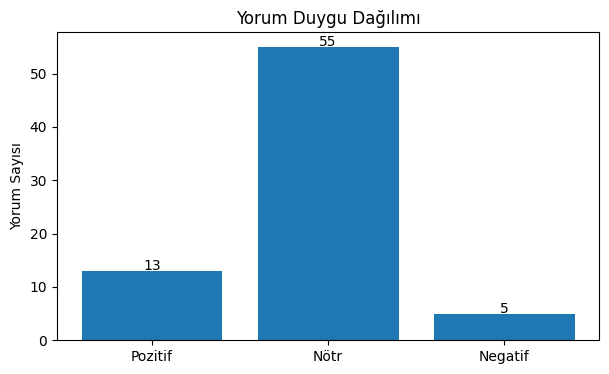

In [17]:
import json
import os
import re
from collections import Counter

input_path = "data/yorumlar.json"

if not os.path.exists(input_path):
    raise FileNotFoundError(f"{input_path} bulunamadı. Önce yorum çekme hücresini çalıştırın.")

with open(input_path, "r", encoding="utf-8") as f:
    yorumlar = json.load(f)

positive_words = {
    "iyi", "guzel", "güzel", "harika", "super", "süper", "mukemmel", "mükemmel", "mutlu", "sevindim",
    "seviyorum", "destek", "dogru", "doğru", "hakli", "haklı", "tebrik", "basarili", "başarılı", "olumlu",
    "kralsin", "kral", "efsane", "helal", "bravo", "mantikli", "mantıklı", "sagol", "sağol", "tamam"
}

negative_words = {
    "kotu", "kötü", "berbat", "sacma", "saçma", "nefret", "rezalet", "yalan", "yanlis", "yanlış",
    "aptal", "salak", "sinir", "biktik", "bıktık", "fiyasko", "utanc", "utanç", "yetersiz", "sorun",
    "problem", "hata", "yaniltici", "yanıltıcı", "bos", "boş", "komik", "alay", "cahil", "teror", "terör"
}

negations = {"degil", "değil", "yok", "hayir", "hayır", "asla"}

emoji_positive = {"😂", "🤣", "😄", "😁", "🙂", "😊", "😍", "🥳", "👍"}
emoji_negative = {"😡", "🤬", "😠", "😤", "😞", "😢", "👎", "💩"}

def tokenize(text):
    return re.findall(r"[\wçğıöşüÇĞİÖŞÜ]+", text.lower(), flags=re.UNICODE)

def sentiment_score(text):
    tokens = tokenize(text)
    score = 0

    for i, token in enumerate(tokens):
        if token in positive_words:
            token_score = 1
        elif token in negative_words:
            token_score = -1
        else:
            token_score = 0

        if token_score != 0 and i > 0 and tokens[i - 1] in negations:
            token_score *= -1

        score += token_score

    for em in emoji_positive:
        score += text.count(em)
    for em in emoji_negative:
        score -= text.count(em)

    return score

def sentiment_label(score):
    if score >= 1:
        return "pozitif"
    if score <= -1:
        return "negatif"
    return "notr"

analiz_sonuclari = []
for row in yorumlar:
    text = row.get("yorum", "")
    score = sentiment_score(text)
    label = sentiment_label(score)
    analiz_sonuclari.append({
        "kullanici": row.get("kullanici", ""),
        "yorum": text,
        "duygu": label,
        "skor": score
    })

counts = Counter(x["duygu"] for x in analiz_sonuclari)
total = len(analiz_sonuclari)

print("=" * 50)
print("DUYGU ANALİZİ ÖZETİ")
print("=" * 50)
print(f"Toplam yorum: {total}")
for k in ["pozitif", "notr", "negatif"]:
    adet = counts.get(k, 0)
    oran = (adet / total * 100) if total else 0
    print(f"- {k:8}: {adet:3} (%{oran:.1f})")

print("\nÖrnek yorumlar:")
for k in ["pozitif", "notr", "negatif"]:
    ornekler = [x for x in analiz_sonuclari if x["duygu"] == k][:3]
    print(f"\n{k.upper()} örnekleri:")
    if not ornekler:
        print("  (yok)")
    for i, o in enumerate(ornekler, 1):
        kisa = o["yorum"].replace("\n", " ")[:110]
        print(f"  {i}. @{o['kullanici']}: {kisa} (skor={o['skor']})")

os.makedirs("data", exist_ok=True)
with open("data/yorumlar_duygu_analizi.json", "w", encoding="utf-8") as f:
    json.dump(analiz_sonuclari, f, ensure_ascii=False, indent=2)

summary = {
    "toplam": total,
    "pozitif": counts.get("pozitif", 0),
    "notr": counts.get("notr", 0),
    "negatif": counts.get("negatif", 0),
    "pozitif_oran": round((counts.get("pozitif", 0) / total * 100), 2) if total else 0,
    "notr_oran": round((counts.get("notr", 0) / total * 100), 2) if total else 0,
    "negatif_oran": round((counts.get("negatif", 0) / total * 100), 2) if total else 0
}

with open("data/duygu_ozet.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("\nKaydedildi:")
print("- data/yorumlar_duygu_analizi.json")
print("- data/duygu_ozet.json")

try:
    import matplotlib.pyplot as plt
    labels = ["Pozitif", "Nötr", "Negatif"]
    values = [counts.get("pozitif", 0), counts.get("notr", 0), counts.get("negatif", 0)]

    plt.figure(figsize=(7, 4))
    bars = plt.bar(labels, values)
    plt.title("Yorum Duygu Dağılımı")
    plt.ylabel("Yorum Sayısı")
    for b in bars:
        plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.1, str(int(b.get_height())), ha="center")
    plt.show()
except Exception as e:
    print(f"Grafik çizimi atlandı: {e}")

🔄 Model yükleniyor (ilk çalıştırmada biraz sürebilir)...


c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 417.00it/s, Materializing param=classifier.weight]                                      



TÜRKÇE BERT + SARKAZM DÜZELTMELİ DUYGU ANALİZİ
Toplam yorum: 73
- pozitif :  37 (%50.7)
- notr    :   4 (%5.5)
- negatif :  32 (%43.8)

🧠 Sarkazm nedeniyle çevrilen yorum: 0

💾 Kaydedildi:
- data/yorumlar_duygu_analizi_bert.json
- data/duygu_ozet_bert.json


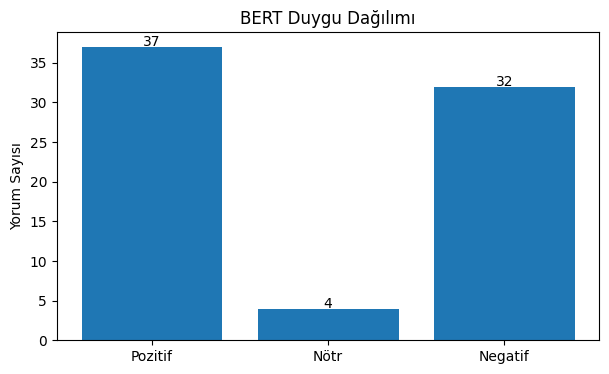

In [18]:
# Türkçe BERT + sarkazm düzeltmeli duygu analizi
import json
import os
import re
from collections import Counter

input_path = "data/yorumlar.json"
if not os.path.exists(input_path):
    raise FileNotFoundError("data/yorumlar.json bulunamadı. Önce yorum çekme hücresini çalıştırın.")

with open(input_path, "r", encoding="utf-8") as f:
    yorumlar = json.load(f)

print("🔄 Model yükleniyor (ilk çalıştırmada biraz sürebilir)...")

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_NAME = "savasy/bert-base-turkish-sentiment-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()

id2label = model.config.id2label

# Sarkazm/alay için hafif kural katmanı
sarcasm_markers = [
    "ciddi olamaz", "yok artık", "aynen", "tabii", "abi ne kullanıyon", "bana da ver",
    "dahi", "helal ya", "çok iyi ya", "harika ya"
]
laugh_markers = ["😂", "🤣", "😅", "😁", "🤪", ":)", ";)"]
negative_clues = ["saçma", "bıktık", "rezalet", "terör", "yalan", "keser", "kıvran", "sus be", "çekilse"]

def clean_text(text: str) -> str:
    text = re.sub(r'https?://t\.co/\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def bert_predict(text: str):
    encoded = tokenizer(
        text,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )
    with torch.no_grad():
        out = model(**encoded)
        probs = torch.softmax(out.logits, dim=-1)[0]

    best_idx = int(torch.argmax(probs).item())
    best_prob = float(probs[best_idx].item())
    raw_label = id2label.get(best_idx, f"LABEL_{best_idx}")

    lbl = str(raw_label).lower()
    if "neg" in lbl or lbl in ["label_0", "0"]:
        return "negatif", best_prob
    if "pos" in lbl or lbl in ["label_1", "1"]:
        return "pozitif", best_prob

    # Beklenmedik label yapısı olursa: en yüksek olasılığa göre binary map
    return ("negatif" if best_idx == 0 else "pozitif"), best_prob

def apply_sarcasm_rules(text: str, label: str, confidence: float):
    lowered = text.lower()
    has_laugh = any(m in text for m in laugh_markers)
    has_sarcasm_phrase = any(m in lowered for m in sarcasm_markers)
    has_negative_clue = any(m in lowered for m in negative_clues)

    # Pozitif ama alay kalıbı + gülme emojisi / negatif ipucu varsa negatife çevir
    if label == "pozitif" and (has_sarcasm_phrase and (has_laugh or has_negative_clue)):
        return "negatif", max(0.55, confidence), "sarcasm_flip"

    # Çok düşük güvende nötrleştir
    if confidence < 0.60:
        return "notr", confidence, "low_confidence"

    return label, confidence, "bert"

sonuclar = []
for row in yorumlar:
    text_raw = row.get("yorum", "")
    text = clean_text(text_raw)

    if not text:
        sonuclar.append({
            "kullanici": row.get("kullanici", ""),
            "yorum": text_raw,
            "duygu": "notr",
            "guven": 0.0,
            "kaynak": "empty"
        })
        continue

    label, conf = bert_predict(text)
    final_label, final_conf, source = apply_sarcasm_rules(text_raw, label, conf)

    sonuclar.append({
        "kullanici": row.get("kullanici", ""),
        "yorum": text_raw,
        "duygu": final_label,
        "guven": round(float(final_conf), 4),
        "kaynak": source,
        "bert_etiket": label,
        "bert_guven": round(float(conf), 4)
    })

counts = Counter(x["duygu"] for x in sonuclar)
total = len(sonuclar)

print("\n" + "=" * 60)
print("TÜRKÇE BERT + SARKAZM DÜZELTMELİ DUYGU ANALİZİ")
print("=" * 60)
print(f"Toplam yorum: {total}")
for k in ["pozitif", "notr", "negatif"]:
    adet = counts.get(k, 0)
    oran = (adet / total * 100) if total else 0
    print(f"- {k:8}: {adet:3} (%{oran:.1f})")

flipped = [x for x in sonuclar if x["kaynak"] == "sarcasm_flip"]
print(f"\n🧠 Sarkazm nedeniyle çevrilen yorum: {len(flipped)}")
for i, r in enumerate(flipped[:5], 1):
    print(f"  {i}. @{r['kullanici']}: {r['yorum'][:110]}")

os.makedirs("data", exist_ok=True)
with open("data/yorumlar_duygu_analizi_bert.json", "w", encoding="utf-8") as f:
    json.dump(sonuclar, f, ensure_ascii=False, indent=2)

summary = {
    "model": MODEL_NAME,
    "toplam": total,
    "pozitif": counts.get("pozitif", 0),
    "notr": counts.get("notr", 0),
    "negatif": counts.get("negatif", 0),
    "pozitif_oran": round((counts.get("pozitif", 0) / total * 100), 2) if total else 0,
    "notr_oran": round((counts.get("notr", 0) / total * 100), 2) if total else 0,
    "negatif_oran": round((counts.get("negatif", 0) / total * 100), 2) if total else 0,
    "sarcasm_flip_sayisi": len(flipped)
}
with open("data/duygu_ozet_bert.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("\n💾 Kaydedildi:")
print("- data/yorumlar_duygu_analizi_bert.json")
print("- data/duygu_ozet_bert.json")

try:
    import matplotlib.pyplot as plt
    labels = ["Pozitif", "Nötr", "Negatif"]
    values = [counts.get("pozitif", 0), counts.get("notr", 0), counts.get("negatif", 0)]

    plt.figure(figsize=(7, 4))
    bars = plt.bar(labels, values)
    plt.title("BERT Duygu Dağılımı")
    plt.ylabel("Yorum Sayısı")
    for b in bars:
        plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.1, str(int(b.get_height())), ha="center")
    plt.show()
except Exception as e:
    print(f"Grafik çizimi atlandı: {e}")